# ✧ Sleep Connection Models Analysis

This notebook creates the connection formulas used in the installation.

The previous notebooks prepared and described the main variables.

This notebook focuses on regression models that connect those variables together.

The main goal is to estimate formulas such as:

caffeine + exercise → predicted_sleep_duration

screen exposure → predicted_sleep_quality_problem

sleep duration + sleep quality → mood, stress, memory, and attention

Important: the datasets are not merged into one large dataset.
Each model is created only within the dataset where the variables belong.

In [1]:
# ------------------------------------------------------------
# Notebook setup
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"
STUDENTLIFE_DIR = DATA_DIR / "studentlife_rds" / "dataset_rds"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project folder: {PROJECT_DIR}")
print(f"NHANES folder: {NHANES_DIR}")
print(f"StudentLife folder: {STUDENTLIFE_DIR}")
print(f"Graphs folder: {GRAPH_DIR}")

Project folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis
NHANES folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\nhanes
StudentLife folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\studentlife_rds\dataset_rds
Graphs folder: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs


## 2. ✧ Preparing the First Connection Model Data

The first connection model predicts average sleep duration from two lifestyle input variables:

caffeine_mg
exercise_min_week

The model uses NHANES 2017–March 2020 data.

The outcome variable is:

avg_sleep_h

This creates the dataset that will later be used to estimate:

predicted_sleep_duration = caffeine + exercise

For this step, we only prepare and check the regression dataset.

In [3]:
# ------------------------------------------------------------
# Prepare data for first connection model:
# caffeine + exercise → avg_sleep_h
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# File paths
sleep_path = NHANES_DIR / "P_SLQ.XPT"
caffeine_path = NHANES_DIR / "P_DR1TOT.XPT"
activity_path = NHANES_DIR / "P_PAQ.XPT"

# Check that the files exist
for file_path in [sleep_path, caffeine_path, activity_path]:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

# ------------------------------------------------------------
# Load NHANES files
# ------------------------------------------------------------

sleep_raw = pd.read_sas(sleep_path, format="xport")
caffeine_raw = pd.read_sas(caffeine_path, format="xport")
activity_raw = pd.read_sas(activity_path, format="xport")

# ------------------------------------------------------------
# Prepare sleep duration variable
# ------------------------------------------------------------

sleep_data = sleep_raw[["SEQN", "SLD012", "SLD013"]].copy()

sleep_data["SLD012"] = pd.to_numeric(
    sleep_data["SLD012"],
    errors="coerce"
)

sleep_data["SLD013"] = pd.to_numeric(
    sleep_data["SLD013"],
    errors="coerce"
)

sleep_data["avg_sleep_h"] = (
    (5 * sleep_data["SLD012"] + 2 * sleep_data["SLD013"]) / 7
)

sleep_data = sleep_data.dropna(
    subset=["avg_sleep_h"]
).copy()

# ------------------------------------------------------------
# Prepare caffeine variable
# ------------------------------------------------------------

caffeine_data = caffeine_raw[["SEQN", "DR1TCAFF"]].copy()

caffeine_data["caffeine_mg"] = pd.to_numeric(
    caffeine_data["DR1TCAFF"],
    errors="coerce"
)

caffeine_data = caffeine_data.dropna(
    subset=["caffeine_mg"]
).copy()

# Apply the earlier cleaned caffeine range
caffeine_data = caffeine_data[
    (caffeine_data["caffeine_mg"] >= 0) &
    (caffeine_data["caffeine_mg"] <= 342.5)
].copy()

# ------------------------------------------------------------
# Prepare exercise variable
# ------------------------------------------------------------

activity_columns = [
    "SEQN",
    "PAQ650", "PAQ655", "PAD660",
    "PAQ665", "PAQ670", "PAD675"
]

activity_data = activity_raw[activity_columns].copy()

for column in activity_columns:
    activity_data[column] = pd.to_numeric(
        activity_data[column],
        errors="coerce"
    )

# Vigorous exercise:
# If PAQ650 = 2, participant did no vigorous activity, so minutes = 0.
# If PAQ650 = 1, use days × minutes.
activity_data["vigorous_min_week"] = np.where(
    activity_data["PAQ650"] == 2,
    0,
    activity_data["PAQ655"] * activity_data["PAD660"]
)

# Moderate exercise:
# If PAQ665 = 2, participant did no moderate activity, so minutes = 0.
# If PAQ665 = 1, use days × minutes.
activity_data["moderate_min_week"] = np.where(
    activity_data["PAQ665"] == 2,
    0,
    activity_data["PAQ670"] * activity_data["PAD675"]
)

activity_data["exercise_min_week"] = (
    activity_data["vigorous_min_week"] +
    activity_data["moderate_min_week"]
)

activity_data = activity_data.dropna(
    subset=["exercise_min_week"]
).copy()

# Apply the earlier cleaned exercise range
activity_data = activity_data[
    (activity_data["exercise_min_week"] >= 0) &
    (activity_data["exercise_min_week"] <= 500)
].copy()

# ------------------------------------------------------------
# Merge into one regression dataset
# ------------------------------------------------------------

sleep_duration_model_data = (
    sleep_data[["SEQN", "avg_sleep_h"]]
    .merge(caffeine_data[["SEQN", "caffeine_mg"]], on="SEQN", how="inner")
    .merge(activity_data[["SEQN", "exercise_min_week"]], on="SEQN", how="inner")
)

sleep_duration_model_data = sleep_duration_model_data.dropna(
    subset=["avg_sleep_h", "caffeine_mg", "exercise_min_week"]
).copy()

# ------------------------------------------------------------
# Check prepared dataset
# ------------------------------------------------------------

sleep_duration_model_summary = (
    sleep_duration_model_data[
        ["avg_sleep_h", "caffeine_mg", "exercise_min_week"]
    ]
    .describe()
    .round(2)
)

print(f"Prepared rows for regression: {len(sleep_duration_model_data):,}")

sleep_duration_model_summary

Prepared rows for regression: 6,658


,avg_sleep_h,caffeine_mg,exercise_min_week
count,6658.00,6658.00,6658.00
mean,7.81,96.27,87.25
std,1.54,94.28,129.11
min,2.00,0.00,0.00
25%,7.00,5.00,0.00
50%,7.93,73.00,0.00
75%,8.71,154.00,150.00
max,14.00,342.00,495.00


## 3. ✧ Fitting the Sleep Duration Connection Model

Now we fit the first linear regression model.

This model predicts average sleep duration from:

caffeine_mg
exercise_min_week

The predictors are standardized before fitting the model.

This means the model uses:

z(caffeine_mg)
z(exercise_min_week)

The outcome variable is:

avg_sleep_h

The model creates the formula for predicted_sleep_duration.

In [6]:
# ------------------------------------------------------------
# Fit first connection model:
# caffeine + exercise → avg_sleep_h
# ------------------------------------------------------------

import numpy as np
import pandas as pd

# Make sure the prepared dataset exists
required_columns = ["avg_sleep_h", "caffeine_mg", "exercise_min_week"]

missing_columns = [
    column for column in required_columns
    if column not in sleep_duration_model_data.columns
]

if missing_columns:
    raise KeyError(f"Missing columns in sleep_duration_model_data: {missing_columns}")

# Create a clean copy for the model
sleep_duration_regression_data = sleep_duration_model_data[
    required_columns
].dropna().copy()

# ------------------------------------------------------------
# Standardize predictors
# ------------------------------------------------------------

caffeine_mean = sleep_duration_regression_data["caffeine_mg"].mean()
caffeine_std = sleep_duration_regression_data["caffeine_mg"].std(ddof=0)

exercise_mean = sleep_duration_regression_data["exercise_min_week"].mean()
exercise_std = sleep_duration_regression_data["exercise_min_week"].std(ddof=0)

sleep_duration_regression_data["caffeine_mg_z"] = (
    (sleep_duration_regression_data["caffeine_mg"] - caffeine_mean) / caffeine_std
)

sleep_duration_regression_data["exercise_min_week_z"] = (
    (sleep_duration_regression_data["exercise_min_week"] - exercise_mean) / exercise_std
)

# ------------------------------------------------------------
# Fit linear regression using numpy
# ------------------------------------------------------------

y = sleep_duration_regression_data["avg_sleep_h"].to_numpy()

X = np.column_stack([
    np.ones(len(sleep_duration_regression_data)),
    sleep_duration_regression_data["caffeine_mg_z"].to_numpy(),
    sleep_duration_regression_data["exercise_min_week_z"].to_numpy(),
])

coefficients = np.linalg.lstsq(X, y, rcond=None)[0]

intercept = coefficients[0]
caffeine_coefficient = coefficients[1]
exercise_coefficient = coefficients[2]

# ------------------------------------------------------------
# Create predictions and calculate R²
# ------------------------------------------------------------

sleep_duration_regression_data["predicted_sleep_duration"] = X @ coefficients

actual_sleep = sleep_duration_regression_data["avg_sleep_h"]
predicted_sleep = sleep_duration_regression_data["predicted_sleep_duration"]

ss_residual = ((actual_sleep - predicted_sleep) ** 2).sum()
ss_total = ((actual_sleep - actual_sleep.mean()) ** 2).sum()

r_squared = 1 - (ss_residual / ss_total)

# ------------------------------------------------------------
# Create model summary table
# ------------------------------------------------------------

sleep_duration_model_coefficients = pd.DataFrame({
    "Model part": [
        "Intercept",
        "z(caffeine_mg)",
        "z(exercise_min_week)",
    ],
    "Coefficient": [
        intercept,
        caffeine_coefficient,
        exercise_coefficient,
    ],
})

sleep_duration_model_coefficients["Coefficient"] = (
    sleep_duration_model_coefficients["Coefficient"].round(4)
)

print(f"Rows used in regression: {len(sleep_duration_regression_data):,}")
print(f"R²: {r_squared:.4f}")

sleep_duration_model_coefficients

Rows used in regression: 6,658
R²: 0.0014


,Model part,Coefficient
0,Intercept,7.8119
1,z(caffeine_mg),-0.0511
2,z(exercise_min_week),-0.0274


## 4. ✧ Preparing the Stronger Sleep Duration Model Data

The first linear regression was very weak.

To create a stronger prediction model, we now prepare a richer dataset.

This version includes three lifestyle input variables:

caffeine_mg
exercise_min_week
sedentary_minutes

The outcome variable is still:

avg_sleep_h

This dataset will be used to compare different prediction models in the next step.

In [8]:
# ------------------------------------------------------------
# Prepare stronger sleep duration model data
# caffeine + exercise + sedentary time → avg_sleep_h
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"
GRAPH_DIR = PROJECT_DIR / "Graphs"

GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# File paths
sleep_path = NHANES_DIR / "P_SLQ.XPT"
caffeine_path = NHANES_DIR / "P_DR1TOT.XPT"
activity_path = NHANES_DIR / "P_PAQ.XPT"

# Load NHANES files
sleep_raw = pd.read_sas(sleep_path, format="xport")
caffeine_raw = pd.read_sas(caffeine_path, format="xport")
activity_raw = pd.read_sas(activity_path, format="xport")

# ------------------------------------------------------------
# Prepare sleep duration variable
# ------------------------------------------------------------

sleep_data = sleep_raw[["SEQN", "SLD012", "SLD013"]].copy()

sleep_data["SLD012"] = pd.to_numeric(
    sleep_data["SLD012"],
    errors="coerce"
)

sleep_data["SLD013"] = pd.to_numeric(
    sleep_data["SLD013"],
    errors="coerce"
)

sleep_data["avg_sleep_h"] = (
    (5 * sleep_data["SLD012"] + 2 * sleep_data["SLD013"]) / 7
)

sleep_data = sleep_data.dropna(
    subset=["avg_sleep_h"]
).copy()

# ------------------------------------------------------------
# Prepare caffeine variable
# ------------------------------------------------------------

caffeine_data = caffeine_raw[["SEQN", "DR1TCAFF"]].copy()

caffeine_data["caffeine_mg"] = pd.to_numeric(
    caffeine_data["DR1TCAFF"],
    errors="coerce"
)

caffeine_data = caffeine_data.dropna(
    subset=["caffeine_mg"]
).copy()

# Apply the earlier cleaned caffeine range
caffeine_data = caffeine_data[
    (caffeine_data["caffeine_mg"] >= 0) &
    (caffeine_data["caffeine_mg"] <= 342.5)
].copy()

# ------------------------------------------------------------
# Prepare exercise and sedentary variables
# ------------------------------------------------------------

activity_columns = [
    "SEQN",
    "PAQ650", "PAQ655", "PAD660",
    "PAQ665", "PAQ670", "PAD675",
    "PAD680"
]

activity_data = activity_raw[activity_columns].copy()

for column in activity_columns:
    activity_data[column] = pd.to_numeric(
        activity_data[column],
        errors="coerce"
    )

# Vigorous exercise
activity_data["vigorous_min_week"] = np.where(
    activity_data["PAQ650"] == 2,
    0,
    activity_data["PAQ655"] * activity_data["PAD660"]
)

# Moderate exercise
activity_data["moderate_min_week"] = np.where(
    activity_data["PAQ665"] == 2,
    0,
    activity_data["PAQ670"] * activity_data["PAD675"]
)

activity_data["exercise_min_week"] = (
    activity_data["vigorous_min_week"] +
    activity_data["moderate_min_week"]
)

# Sedentary time
activity_data["sedentary_minutes"] = activity_data["PAD680"]

# Keep only valid rows
activity_data = activity_data.dropna(
    subset=["exercise_min_week", "sedentary_minutes"]
).copy()

# Apply earlier exercise range
activity_data = activity_data[
    (activity_data["exercise_min_week"] >= 0) &
    (activity_data["exercise_min_week"] <= 500)
].copy()

# Remove impossible or special sedentary values
activity_data = activity_data[
    (activity_data["sedentary_minutes"] >= 0) &
    (activity_data["sedentary_minutes"] <= 1320)
].copy()

# ------------------------------------------------------------
# Merge into stronger model dataset
# ------------------------------------------------------------

strong_sleep_duration_model_data = (
    sleep_data[["SEQN", "avg_sleep_h"]]
    .merge(caffeine_data[["SEQN", "caffeine_mg"]], on="SEQN", how="inner")
    .merge(
        activity_data[["SEQN", "exercise_min_week", "sedentary_minutes"]],
        on="SEQN",
        how="inner"
    )
)

strong_sleep_duration_model_data = strong_sleep_duration_model_data.dropna(
    subset=[
        "avg_sleep_h",
        "caffeine_mg",
        "exercise_min_week",
        "sedentary_minutes"
    ]
).copy()

# ------------------------------------------------------------
# Check the prepared stronger dataset
# ------------------------------------------------------------

strong_sleep_duration_model_summary = (
    strong_sleep_duration_model_data[
        [
            "avg_sleep_h",
            "caffeine_mg",
            "exercise_min_week",
            "sedentary_minutes"
        ]
    ]
    .describe()
    .round(2)
)

print(f"Prepared rows for stronger model comparison: {len(strong_sleep_duration_model_data):,}")

strong_sleep_duration_model_summary

Prepared rows for stronger model comparison: 6,622


,avg_sleep_h,caffeine_mg,exercise_min_week,sedentary_minutes
count,6622.00,6622.00,6622.00,6622.00
mean,7.81,96.34,87.44,338.85
std,1.54,94.24,129.24,204.52
min,2.00,0.00,0.00,0.00
25%,7.00,5.00,0.00,180.00
50%,7.93,73.00,0.00,300.00
75%,8.71,154.00,150.00,480.00
max,14.00,342.00,495.00,1320.00


## 5. ✧ Model A: Comparing Sleep Duration Prediction Models

Model A predicts average sleep duration using only the input variables already planned for the installation:

caffeine_mg
exercise_min_week

The outcome variable is:

avg_sleep_h

This model does not include sedentary time yet.

The goal is to compare different prediction models and see whether a more complex model predicts sleep duration better than a simple baseline.

In [9]:
# ------------------------------------------------------------
# Model A: Compare sleep duration prediction models
# caffeine + exercise → avg_sleep_h
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Prepare Model A variables
# ------------------------------------------------------------

model_a_predictor_columns = [
    "caffeine_mg",
    "exercise_min_week"
]

model_a_outcome_column = "avg_sleep_h"

# Use the prepared dataset from the earlier Model A preparation step
model_a_data = sleep_duration_model_data[
    model_a_predictor_columns + [model_a_outcome_column]
].dropna().copy()

X_a = model_a_data[model_a_predictor_columns]
y_a = model_a_data[model_a_outcome_column]

# Split into training and testing data
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a,
    y_a,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Define Model A candidates
# ------------------------------------------------------------

model_a_candidates = {
    "Baseline mean model": DummyRegressor(strategy="mean"),

    "Linear regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Polynomial ridge regression": Pipeline([
        ("scaler", StandardScaler()),
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random forest regression": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),

    "Gradient boosting regression": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )
}

# ------------------------------------------------------------
# Train and evaluate each Model A candidate
# ------------------------------------------------------------

model_a_results = []
model_a_fitted_models = {}

for model_name, model in model_a_candidates.items():
    # Fit model
    model.fit(X_a_train, y_a_train)

    # Store fitted model for later use
    model_a_fitted_models[model_name] = model

    # Predict on test data
    y_a_pred = model.predict(X_a_test)

    # Calculate evaluation metrics
    test_r2 = r2_score(y_a_test, y_a_pred)
    test_mae = mean_absolute_error(y_a_test, y_a_pred)
    test_rmse = np.sqrt(mean_squared_error(y_a_test, y_a_pred))

    model_a_results.append({
        "model": model_name,
        "test_R2": round(test_r2, 4),
        "test_MAE_hours": round(test_mae, 4),
        "test_RMSE_hours": round(test_rmse, 4)
    })

# Create comparison table
model_a_sleep_duration_comparison = pd.DataFrame(model_a_results)

# Sort by lowest average prediction error
model_a_sleep_duration_comparison = (
    model_a_sleep_duration_comparison
    .sort_values(by="test_MAE_hours")
    .reset_index(drop=True)
)

print(f"Model A training rows: {len(X_a_train):,}")
print(f"Model A testing rows: {len(X_a_test):,}")

model_a_sleep_duration_comparison

Model A training rows: 5,326
Model A testing rows: 1,332


,model,test_R2,test_MAE_hours,test_RMSE_hours
0,Linear regression,-0.0019,1.1483,1.5484
1,Polynomial ridge regression,-0.0023,1.1495,1.5487
2,Baseline mean model,-0.0047,1.1501,1.5505
3,Gradient boosting regression,-0.0138,1.1627,1.5576
4,Random forest regression,-0.0449,1.1869,1.5813


## 6. ✧ Model B: Adding Sedentary Time

Model B predicts average sleep duration using three lifestyle variables:

caffeine_mg
exercise_min_week
sedentary_minutes

The outcome variable is:

avg_sleep_h

This model tests whether adding sedentary time improves sleep duration prediction.

This version is optional for the installation, because sedentary time has not yet been fully decided as a user input.

In [10]:
# ------------------------------------------------------------
# Model B: Compare sleep duration prediction models
# caffeine + exercise + sedentary time → avg_sleep_h
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Prepare Model B variables
# ------------------------------------------------------------

model_b_predictor_columns = [
    "caffeine_mg",
    "exercise_min_week",
    "sedentary_minutes"
]

model_b_outcome_column = "avg_sleep_h"

# Use the prepared stronger dataset from the earlier Model B preparation step
model_b_data = strong_sleep_duration_model_data[
    model_b_predictor_columns + [model_b_outcome_column]
].dropna().copy()

X_b = model_b_data[model_b_predictor_columns]
y_b = model_b_data[model_b_outcome_column]

# Split into training and testing data
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b,
    y_b,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Define Model B candidates
# ------------------------------------------------------------

model_b_candidates = {
    "Baseline mean model": DummyRegressor(strategy="mean"),

    "Linear regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Polynomial ridge regression": Pipeline([
        ("scaler", StandardScaler()),
        ("polynomial_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random forest regression": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),

    "Gradient boosting regression": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )
}

# ------------------------------------------------------------
# Train and evaluate each Model B candidate
# ------------------------------------------------------------

model_b_results = []
model_b_fitted_models = {}

for model_name, model in model_b_candidates.items():
    # Fit model
    model.fit(X_b_train, y_b_train)

    # Store fitted model for later use
    model_b_fitted_models[model_name] = model

    # Predict on test data
    y_b_pred = model.predict(X_b_test)

    # Calculate evaluation metrics
    test_r2 = r2_score(y_b_test, y_b_pred)
    test_mae = mean_absolute_error(y_b_test, y_b_pred)
    test_rmse = np.sqrt(mean_squared_error(y_b_test, y_b_pred))

    model_b_results.append({
        "model": model_name,
        "test_R2": round(test_r2, 4),
        "test_MAE_hours": round(test_mae, 4),
        "test_RMSE_hours": round(test_rmse, 4)
    })

# Create comparison table
model_b_sleep_duration_comparison = pd.DataFrame(model_b_results)

# Sort by lowest average prediction error
model_b_sleep_duration_comparison = (
    model_b_sleep_duration_comparison
    .sort_values(by="test_MAE_hours")
    .reset_index(drop=True)
)

print(f"Model B training rows: {len(X_b_train):,}")
print(f"Model B testing rows: {len(X_b_test):,}")

model_b_sleep_duration_comparison

Model B training rows: 5,297
Model B testing rows: 1,325


,model,test_R2,test_MAE_hours,test_RMSE_hours
0,Polynomial ridge regression,-0.0022,1.1751,1.5490
1,Baseline mean model,-0.0046,1.1780,1.5509
2,Linear regression,-0.0046,1.1785,1.5509
3,Gradient boosting regression,-0.0158,1.1792,1.5595
4,Random forest regression,-0.0687,1.2138,1.5996


## 7. ✧ Visual Checking Model A and Model B Predictions

The previous tables showed that Model A and Model B had weak prediction scores.

Now we visually compare predicted sleep duration with actual sleep duration.

Each point represents one participant in the test set.

The diagonal line represents perfect prediction.

If the model predicts well, the points should follow the diagonal line.

If the model predicts poorly, the points will form a loose cloud and stay close to the average predicted sleep duration.

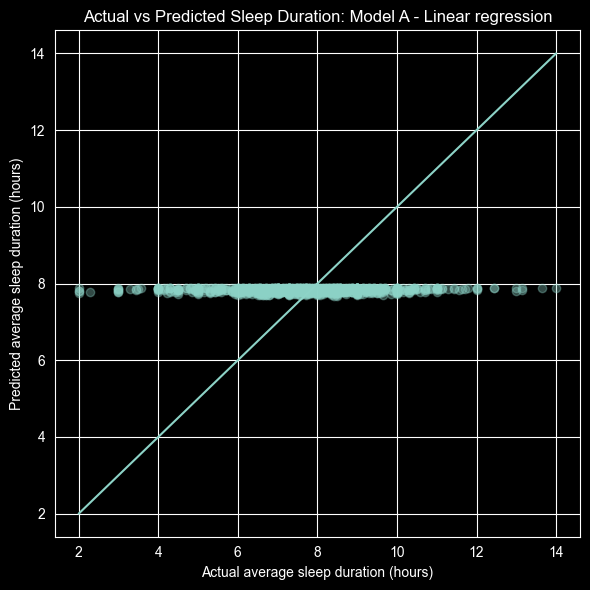

Model: Model A - Linear regression
Test R²: -0.0019
Test MAE: 1.1483 hours
Test RMSE: 1.5484 hours
Graph saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\model_a_actual_vs_predicted_sleep_duration.png


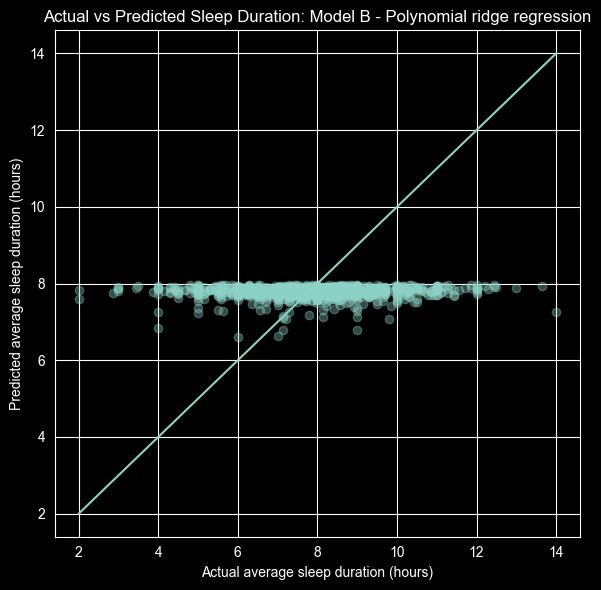

Model: Model B - Polynomial ridge regression
Test R²: -0.0022
Test MAE: 1.1751 hours
Test RMSE: 1.5490 hours
Graph saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\model_b_actual_vs_predicted_sleep_duration.png


,actual_avg_sleep_h,predicted_avg_sleep_h,prediction_error_h
0,8.71,7.79,-0.93
1,6.86,7.82,0.96
2,5.14,7.79,2.65
3,10.00,7.89,-2.11
4,7.00,7.88,0.88
5,8.71,7.86,-0.85
6,8.00,7.88,-0.12
7,5.29,7.79,2.50
8,7.86,7.83,-0.03
9,6.64,7.77,1.12


In [11]:
# ------------------------------------------------------------
# Visual check: actual vs predicted sleep duration
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Re-create GRAPH_DIR in case PyCharm/Jupyter forgot it
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helper function for prediction checking
# ------------------------------------------------------------

def create_prediction_check_plot(
    model_name,
    fitted_model,
    X_test,
    y_test,
    graph_filename
):
    """
    Create an actual vs predicted plot for a sleep duration model.
    """

    # Predict sleep duration
    y_pred = fitted_model.predict(X_test)

    # Calculate model metrics
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Create a small prediction check table
    prediction_check_table = pd.DataFrame({
        "actual_avg_sleep_h": y_test.to_numpy(),
        "predicted_avg_sleep_h": y_pred,
        "prediction_error_h": y_pred - y_test.to_numpy()
    })

    prediction_check_table = prediction_check_table.round(2)

    # Create plot boundaries
    lower_limit = min(
        prediction_check_table["actual_avg_sleep_h"].min(),
        prediction_check_table["predicted_avg_sleep_h"].min()
    )

    upper_limit = max(
        prediction_check_table["actual_avg_sleep_h"].max(),
        prediction_check_table["predicted_avg_sleep_h"].max()
    )

    # Create graph
    plt.figure(figsize=(6, 6))

    plt.scatter(
        prediction_check_table["actual_avg_sleep_h"],
        prediction_check_table["predicted_avg_sleep_h"],
        alpha=0.35
    )

    # Diagonal reference line for perfect prediction
    plt.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit]
    )

    plt.title(f"Actual vs Predicted Sleep Duration: {model_name}")
    plt.xlabel("Actual average sleep duration (hours)")
    plt.ylabel("Predicted average sleep duration (hours)")
    plt.tight_layout()

    # Save graph
    graph_path = GRAPH_DIR / graph_filename
    plt.savefig(graph_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Model: {model_name}")
    print(f"Test R²: {test_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f} hours")
    print(f"Test RMSE: {test_rmse:.4f} hours")
    print(f"Graph saved to: {graph_path}")

    return prediction_check_table


# ------------------------------------------------------------
# Model A: choose best model based on lowest MAE
# ------------------------------------------------------------

best_model_a_name = model_a_sleep_duration_comparison.iloc[0]["model"]
best_model_a = model_a_fitted_models[best_model_a_name]

model_a_prediction_check = create_prediction_check_plot(
    model_name=f"Model A - {best_model_a_name}",
    fitted_model=best_model_a,
    X_test=X_a_test,
    y_test=y_a_test,
    graph_filename="model_a_actual_vs_predicted_sleep_duration.png"
)

# ------------------------------------------------------------
# Model B: choose best model based on lowest MAE
# ------------------------------------------------------------

best_model_b_name = model_b_sleep_duration_comparison.iloc[0]["model"]
best_model_b = model_b_fitted_models[best_model_b_name]

model_b_prediction_check = create_prediction_check_plot(
    model_name=f"Model B - {best_model_b_name}",
    fitted_model=best_model_b,
    X_test=X_b_test,
    y_test=y_b_test,
    graph_filename="model_b_actual_vs_predicted_sleep_duration.png"
)

# Show a small sample from Model A
model_a_prediction_check.head(10)

## 8. ✧ Visualizing Caffeine, Exercise, and Sleep Duration

Before testing more complex models, we first visualize the relationship between the main input variables and sleep duration.

This graph shows:

caffeine_mg on the x-axis
exercise_min_week on the y-axis
avg_sleep_h as the dot color

Each dot represents one participant.

If caffeine and exercise strongly relate to sleep duration, we may see visible regions where sleep duration becomes higher or lower.

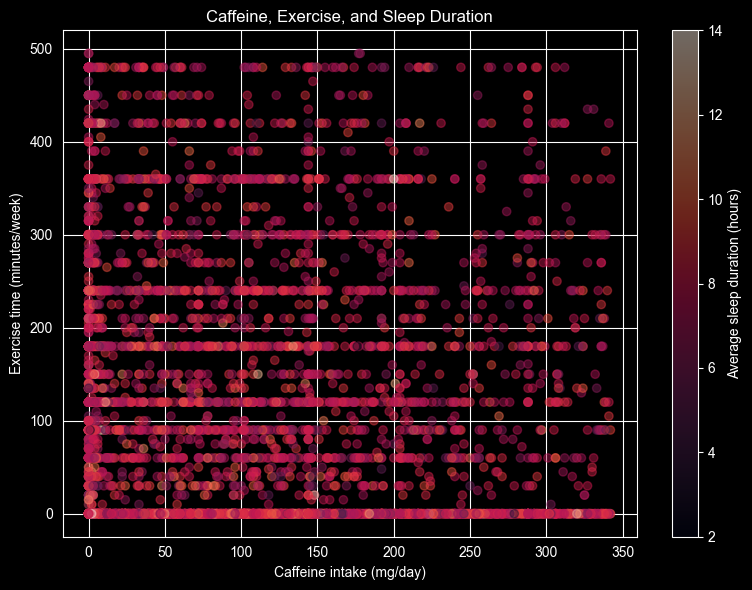

Graph saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\caffeine_exercise_sleep_duration_scatter.png


In [12]:
# ------------------------------------------------------------
# Visualize caffeine, exercise, and sleep duration
# ------------------------------------------------------------

from pathlib import Path
import matplotlib.pyplot as plt

# Re-create GRAPH_DIR in case PyCharm/Jupyter forgot it
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Use Model A data because it matches the current installation inputs
visual_model_a_data = sleep_duration_model_data[
    ["caffeine_mg", "exercise_min_week", "avg_sleep_h"]
].dropna().copy()

# Create scatter plot
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    visual_model_a_data["caffeine_mg"],
    visual_model_a_data["exercise_min_week"],
    c=visual_model_a_data["avg_sleep_h"],
    alpha=0.45
)

plt.title("Caffeine, Exercise, and Sleep Duration")
plt.xlabel("Caffeine intake (mg/day)")
plt.ylabel("Exercise time (minutes/week)")

# Add colorbar to explain sleep duration
colorbar = plt.colorbar(scatter)
colorbar.set_label("Average sleep duration (hours)")

plt.tight_layout()

# Save graph
caffeine_exercise_sleep_graph_path = (
    GRAPH_DIR / "caffeine_exercise_sleep_duration_scatter.png"
)

plt.savefig(
    caffeine_exercise_sleep_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Graph saved to: {caffeine_exercise_sleep_graph_path}")

## 9. ✧ Binned Heatmap of Caffeine, Exercise, and Sleep Duration

The previous scatter plot was difficult to interpret because many participants overlap.

Now we create a binned heatmap.

The data is grouped into caffeine ranges and exercise ranges.

Each cell shows the average sleep duration for participants in that caffeine/exercise combination.

This helps us check whether sleep duration changes across lifestyle patterns before trying more complex models.

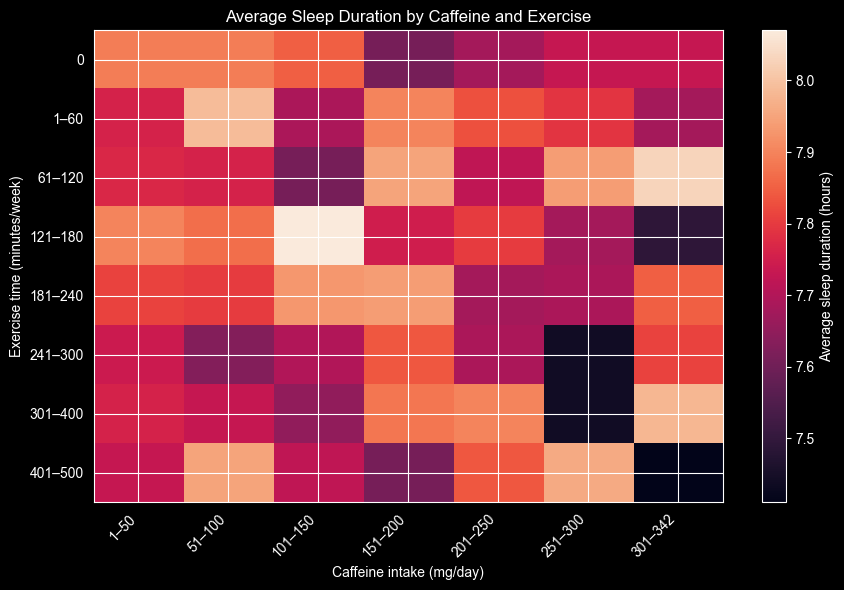

Mean sleep heatmap saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\caffeine_exercise_mean_sleep_heatmap.png


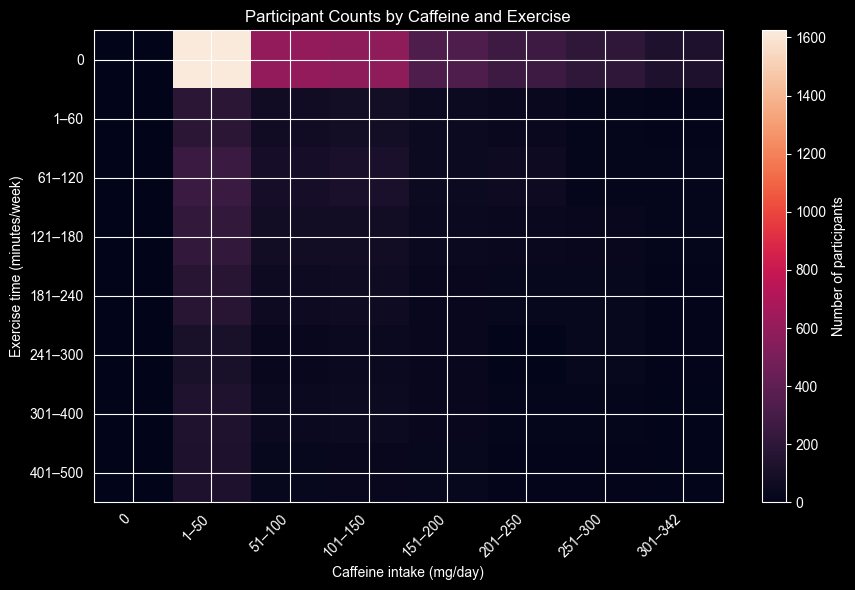

Count heatmap saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\caffeine_exercise_count_heatmap.png
Average sleep duration table:


caffeine_bin,1–50,51–100,101–150,151–200,201–250,251–300,301–342
exercise_bin,,,,,,,
0,7.89,7.89,7.85,7.61,7.68,7.73,7.73
1–60,7.76,7.99,7.69,7.90,7.83,7.79,7.68
61–120,7.77,7.76,7.61,7.95,7.72,7.94,8.03
121–180,7.90,7.87,8.07,7.75,7.80,7.68,7.49
181–240,7.81,7.80,7.93,7.94,7.68,7.69,7.85
241–300,7.74,7.63,7.70,7.84,7.69,7.44,7.81
301–400,7.76,7.73,7.65,7.88,7.90,7.44,7.98
401–500,7.73,7.95,7.72,7.61,7.84,7.96,7.41


Participant count table:


caffeine_bin,0,1–50,51–100,101–150,151–200,201–250,251–300,301–342
exercise_bin,,,,,,,,
0,0,1624,605,583,332,262,205,131
1–60,0,186,71,86,57,44,24,17
61–120,0,256,98,117,57,60,21,21
121–180,0,219,81,81,45,40,38,21
181–240,0,176,59,65,36,31,29,16
241–300,0,112,36,49,33,11,26,15
301–400,0,135,47,56,33,20,20,7
401–500,0,129,30,37,27,15,16,10


In [13]:
# ------------------------------------------------------------
# Binned heatmap: caffeine + exercise → average sleep duration
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Re-create GRAPH_DIR in case PyCharm/Jupyter forgot it
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# Use Model A data because it matches the current installation inputs
heatmap_data = sleep_duration_model_data[
    ["caffeine_mg", "exercise_min_week", "avg_sleep_h"]
].dropna().copy()

# ------------------------------------------------------------
# Create readable bins
# ------------------------------------------------------------

caffeine_bins = [-0.1, 0, 50, 100, 150, 200, 250, 300, 342.5]
caffeine_labels = [
    "0",
    "1–50",
    "51–100",
    "101–150",
    "151–200",
    "201–250",
    "251–300",
    "301–342"
]

exercise_bins = [-0.1, 0, 60, 120, 180, 240, 300, 400, 500]
exercise_labels = [
    "0",
    "1–60",
    "61–120",
    "121–180",
    "181–240",
    "241–300",
    "301–400",
    "401–500"
]

heatmap_data["caffeine_bin"] = pd.cut(
    heatmap_data["caffeine_mg"],
    bins=caffeine_bins,
    labels=caffeine_labels,
    include_lowest=True
)

heatmap_data["exercise_bin"] = pd.cut(
    heatmap_data["exercise_min_week"],
    bins=exercise_bins,
    labels=exercise_labels,
    include_lowest=True
)

# ------------------------------------------------------------
# Create mean sleep duration table
# ------------------------------------------------------------

mean_sleep_heatmap_table = heatmap_data.pivot_table(
    values="avg_sleep_h",
    index="exercise_bin",
    columns="caffeine_bin",
    aggfunc="mean",
    observed=False
).round(2)

# Also create a count table so we know how many people are in each cell
count_heatmap_table = heatmap_data.pivot_table(
    values="avg_sleep_h",
    index="exercise_bin",
    columns="caffeine_bin",
    aggfunc="count",
    observed=False
).fillna(0).astype(int)

# ------------------------------------------------------------
# Graph 1: average sleep duration heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.imshow(
    mean_sleep_heatmap_table,
    aspect="auto"
)

plt.title("Average Sleep Duration by Caffeine and Exercise")
plt.xlabel("Caffeine intake (mg/day)")
plt.ylabel("Exercise time (minutes/week)")

plt.xticks(
    ticks=np.arange(len(mean_sleep_heatmap_table.columns)),
    labels=mean_sleep_heatmap_table.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(mean_sleep_heatmap_table.index)),
    labels=mean_sleep_heatmap_table.index
)

colorbar = plt.colorbar()
colorbar.set_label("Average sleep duration (hours)")

plt.tight_layout()

mean_heatmap_path = GRAPH_DIR / "caffeine_exercise_mean_sleep_heatmap.png"
plt.savefig(mean_heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Mean sleep heatmap saved to: {mean_heatmap_path}")

# ------------------------------------------------------------
# Graph 2: count heatmap
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))

plt.imshow(
    count_heatmap_table,
    aspect="auto"
)

plt.title("Participant Counts by Caffeine and Exercise")
plt.xlabel("Caffeine intake (mg/day)")
plt.ylabel("Exercise time (minutes/week)")

plt.xticks(
    ticks=np.arange(len(count_heatmap_table.columns)),
    labels=count_heatmap_table.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(count_heatmap_table.index)),
    labels=count_heatmap_table.index
)

colorbar = plt.colorbar()
colorbar.set_label("Number of participants")

plt.tight_layout()

count_heatmap_path = GRAPH_DIR / "caffeine_exercise_count_heatmap.png"
plt.savefig(count_heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Count heatmap saved to: {count_heatmap_path}")

# Show tables too
print("Average sleep duration table:")
display(mean_sleep_heatmap_table)

print("Participant count table:")
display(count_heatmap_table)

## 10. ✧ Model C: Binned Lookup Prediction Model

Now we test a binned lookup model.

Instead of fitting a smooth regression line, this model uses caffeine and exercise categories.

For each caffeine/exercise combination, the model learns the average sleep duration from the training data.

Then it predicts sleep duration for the test data using the matching category combination.

This model is more similar to how the installation may work:

user input → category → predicted sleep duration

We test both:

raw lookup model
smoothed lookup model

The smoothed version reduces extreme effects from small participant groups.
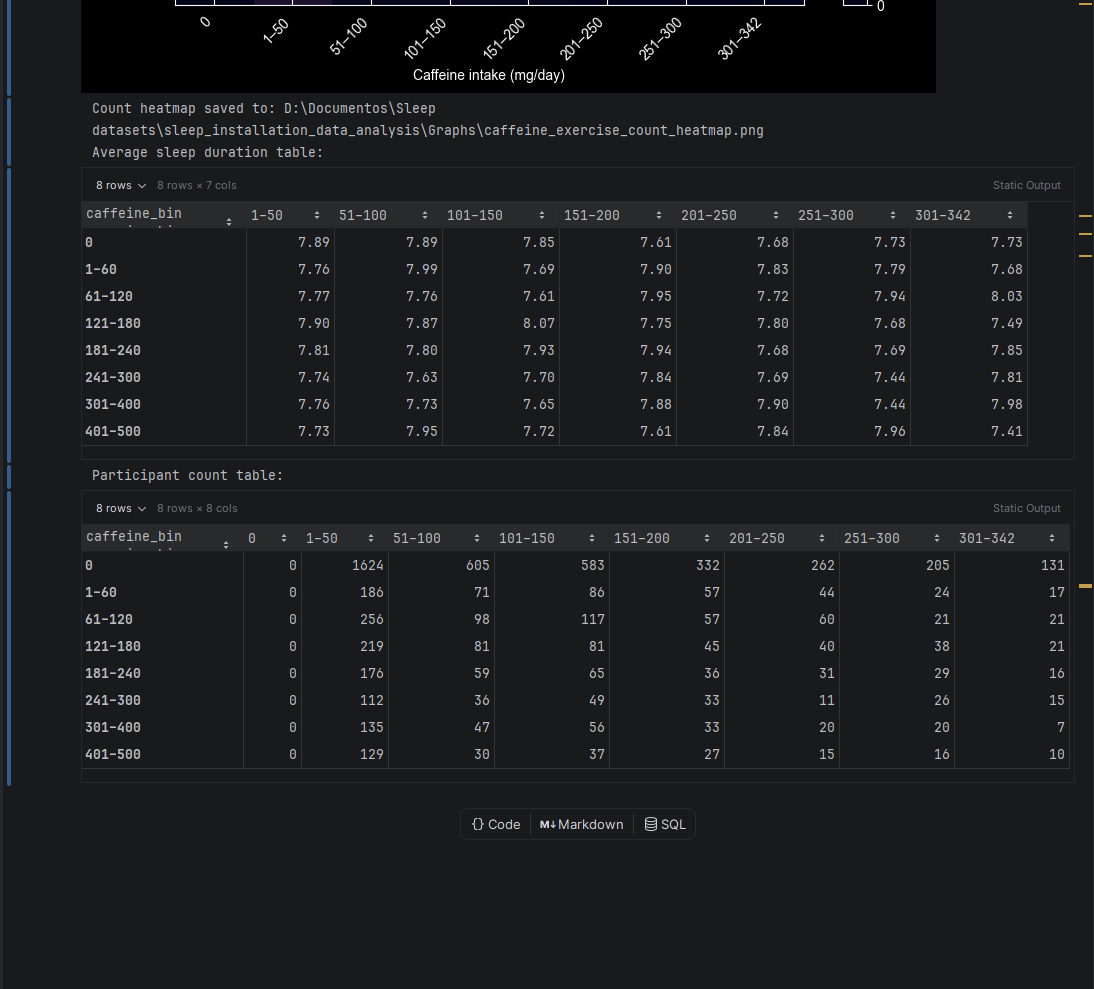

Model C training rows: 5,326
Model C testing rows: 1,332


,model,test_R2,test_MAE_hours,test_RMSE_hours
0,Baseline mean model,-0.0047,1.1501,1.5505
1,Smoothed binned lookup model,-0.0094,1.1546,1.5542
2,Raw binned lookup model,-0.0147,1.1587,1.5582


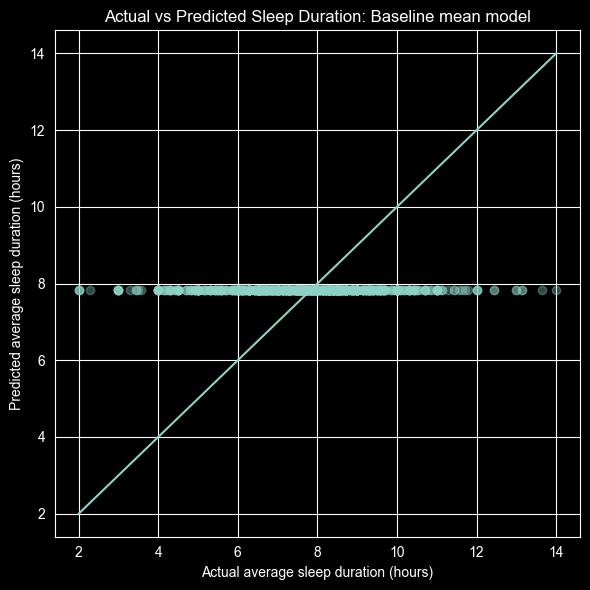

Best Model C version: Baseline mean model
Graph saved to: D:\Documentos\Sleep datasets\sleep_installation_data_analysis\Graphs\model_c_actual_vs_predicted_sleep_duration.png


,actual_avg_sleep_h,predicted_avg_sleep_h,prediction_error_h
0,8.71,7.83,-0.88
1,6.86,7.83,0.98
2,5.14,7.83,2.69
3,10.00,7.83,-2.17
4,7.00,7.83,0.83
5,8.71,7.83,-0.88
6,8.00,7.83,-0.17
7,5.29,7.83,2.55
8,7.86,7.83,-0.02
9,6.64,7.83,1.19


In [14]:
# ------------------------------------------------------------
# Model C: Binned lookup model
# caffeine bin + exercise bin → avg_sleep_h
# ------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

GRAPH_DIR = PROJECT_DIR / "Graphs"
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Prepare Model C data
# ------------------------------------------------------------

model_c_data = sleep_duration_model_data[
    ["caffeine_mg", "exercise_min_week", "avg_sleep_h"]
].dropna().copy()

# Use the same bins as the heatmap
caffeine_bins = [-0.1, 0, 50, 100, 150, 200, 250, 300, 342.5]
caffeine_labels = [
    "0",
    "1–50",
    "51–100",
    "101–150",
    "151–200",
    "201–250",
    "251–300",
    "301–342"
]

exercise_bins = [-0.1, 0, 60, 120, 180, 240, 300, 400, 500]
exercise_labels = [
    "0",
    "1–60",
    "61–120",
    "121–180",
    "181–240",
    "241–300",
    "301–400",
    "401–500"
]

# ------------------------------------------------------------
# Helper function to add bins
# ------------------------------------------------------------

def add_caffeine_exercise_bins(data):
    """
    Add caffeine and exercise category bins to the data.
    """

    data = data.copy()

    data["caffeine_bin"] = pd.cut(
        data["caffeine_mg"],
        bins=caffeine_bins,
        labels=caffeine_labels,
        include_lowest=True
    )

    data["exercise_bin"] = pd.cut(
        data["exercise_min_week"],
        bins=exercise_bins,
        labels=exercise_labels,
        include_lowest=True
    )

    data = data.dropna(
        subset=["caffeine_bin", "exercise_bin"]
    ).copy()

    data["caffeine_bin"] = data["caffeine_bin"].astype(str)
    data["exercise_bin"] = data["exercise_bin"].astype(str)

    return data


# ------------------------------------------------------------
# Train/test split
# ------------------------------------------------------------

model_c_train, model_c_test = train_test_split(
    model_c_data,
    test_size=0.20,
    random_state=42
)

model_c_train = add_caffeine_exercise_bins(model_c_train)
model_c_test = add_caffeine_exercise_bins(model_c_test)

global_train_mean = model_c_train["avg_sleep_h"].mean()

# ------------------------------------------------------------
# Build lookup table from training data only
# ------------------------------------------------------------

model_c_lookup_table = (
    model_c_train
    .groupby(["caffeine_bin", "exercise_bin"], observed=True)
    .agg(
        mean_sleep_duration=("avg_sleep_h", "mean"),
        participant_count=("avg_sleep_h", "count")
    )
    .reset_index()
)

# Create raw lookup dictionary
raw_lookup = {}

for _, row in model_c_lookup_table.iterrows():
    key = (row["caffeine_bin"], row["exercise_bin"])
    raw_lookup[key] = row["mean_sleep_duration"]

# Create smoothed lookup dictionary
# Larger smoothing_strength = more conservative predictions
smoothing_strength = 20

smoothed_lookup = {}

for _, row in model_c_lookup_table.iterrows():
    key = (row["caffeine_bin"], row["exercise_bin"])

    cell_mean = row["mean_sleep_duration"]
    cell_count = row["participant_count"]

    smoothed_mean = (
        (cell_count * cell_mean) +
        (smoothing_strength * global_train_mean)
    ) / (cell_count + smoothing_strength)

    smoothed_lookup[key] = smoothed_mean


# ------------------------------------------------------------
# Helper function for lookup prediction
# ------------------------------------------------------------

def predict_from_lookup(data, lookup_dictionary, fallback_value):
    """
    Predict sleep duration using caffeine/exercise bin lookup.
    If a bin combination was not seen in training, use fallback value.
    """

    predictions = []

    for _, row in data.iterrows():
        key = (row["caffeine_bin"], row["exercise_bin"])
        prediction = lookup_dictionary.get(key, fallback_value)
        predictions.append(prediction)

    return np.array(predictions)


# ------------------------------------------------------------
# Make predictions
# ------------------------------------------------------------

y_c_test = model_c_test["avg_sleep_h"].to_numpy()

baseline_predictions = np.full(
    shape=len(model_c_test),
    fill_value=global_train_mean
)

raw_lookup_predictions = predict_from_lookup(
    data=model_c_test,
    lookup_dictionary=raw_lookup,
    fallback_value=global_train_mean
)

smoothed_lookup_predictions = predict_from_lookup(
    data=model_c_test,
    lookup_dictionary=smoothed_lookup,
    fallback_value=global_train_mean
)

# ------------------------------------------------------------
# Evaluate models
# ------------------------------------------------------------

def evaluate_regression_model(model_name, actual_values, predicted_values):
    """
    Return R², MAE, and RMSE for a regression model.
    """

    test_r2 = r2_score(actual_values, predicted_values)
    test_mae = mean_absolute_error(actual_values, predicted_values)
    test_rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))

    return {
        "model": model_name,
        "test_R2": round(test_r2, 4),
        "test_MAE_hours": round(test_mae, 4),
        "test_RMSE_hours": round(test_rmse, 4)
    }


model_c_results = [
    evaluate_regression_model(
        "Baseline mean model",
        y_c_test,
        baseline_predictions
    ),
    evaluate_regression_model(
        "Raw binned lookup model",
        y_c_test,
        raw_lookup_predictions
    ),
    evaluate_regression_model(
        "Smoothed binned lookup model",
        y_c_test,
        smoothed_lookup_predictions
    )
]

model_c_comparison = pd.DataFrame(model_c_results)

model_c_comparison = (
    model_c_comparison
    .sort_values(by="test_MAE_hours")
    .reset_index(drop=True)
)

print(f"Model C training rows: {len(model_c_train):,}")
print(f"Model C testing rows: {len(model_c_test):,}")

display(model_c_comparison)

# ------------------------------------------------------------
# Create actual vs predicted graph for the best Model C version
# ------------------------------------------------------------

best_model_c_name = model_c_comparison.iloc[0]["model"]

if best_model_c_name == "Raw binned lookup model":
    best_model_c_predictions = raw_lookup_predictions
elif best_model_c_name == "Smoothed binned lookup model":
    best_model_c_predictions = smoothed_lookup_predictions
else:
    best_model_c_predictions = baseline_predictions

model_c_prediction_check = pd.DataFrame({
    "actual_avg_sleep_h": y_c_test,
    "predicted_avg_sleep_h": best_model_c_predictions,
    "prediction_error_h": best_model_c_predictions - y_c_test
}).round(2)

lower_limit = min(
    model_c_prediction_check["actual_avg_sleep_h"].min(),
    model_c_prediction_check["predicted_avg_sleep_h"].min()
)

upper_limit = max(
    model_c_prediction_check["actual_avg_sleep_h"].max(),
    model_c_prediction_check["predicted_avg_sleep_h"].max()
)

plt.figure(figsize=(6, 6))

plt.scatter(
    model_c_prediction_check["actual_avg_sleep_h"],
    model_c_prediction_check["predicted_avg_sleep_h"],
    alpha=0.35
)

plt.plot(
    [lower_limit, upper_limit],
    [lower_limit, upper_limit]
)

plt.title(f"Actual vs Predicted Sleep Duration: {best_model_c_name}")
plt.xlabel("Actual average sleep duration (hours)")
plt.ylabel("Predicted average sleep duration (hours)")
plt.tight_layout()

model_c_graph_path = GRAPH_DIR / "model_c_actual_vs_predicted_sleep_duration.png"

plt.savefig(
    model_c_graph_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Best Model C version: {best_model_c_name}")
print(f"Graph saved to: {model_c_graph_path}")

# Show a small sample of predictions
model_c_prediction_check.head(10)

## 11. ✧ Fixing Model D Encoding

The first Model D run stopped because one model required dense input data.

The issue came from the one-hot encoded category variables.

Now we rerun the same model comparison, but we force the encoded category variables to become dense instead of sparse.

This does not change the analysis idea.

It only fixes the data format given to the models.

In [17]:
# ------------------------------------------------------------
# Model D fix: rerun model search with dense one-hot encoding
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR

# ------------------------------------------------------------
# Make dense OneHotEncoder
# ------------------------------------------------------------

# Newer sklearn uses sparse_output=False.
# Older sklearn uses sparse=False.
try:
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# ------------------------------------------------------------
# Recreate preprocessors with dense encoding
# ------------------------------------------------------------

standard_preprocessor_dense = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", dense_one_hot_encoder, categorical_features),
    ]
)

tree_preprocessor_dense = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_features),
        ("categorical", dense_one_hot_encoder, categorical_features),
    ]
)

# ------------------------------------------------------------
# Define Model D candidates again
# ------------------------------------------------------------

model_d_candidates_dense = {
    "Baseline mean model": DummyRegressor(strategy="mean"),

    "Extra Trees conservative": Pipeline([
        ("preprocessor", tree_preprocessor_dense),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees flexible": Pipeline([
        ("preprocessor", tree_preprocessor_dense),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("preprocessor", tree_preprocessor_dense),
        ("model", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=15,
            random_state=42
        ))
    ]),

    "Random Forest flexible": Pipeline([
        ("preprocessor", tree_preprocessor_dense),
        ("model", RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "KNN regression": Pipeline([
        ("preprocessor", standard_preprocessor_dense),
        ("model", KNeighborsRegressor(
            n_neighbors=35,
            weights="distance"
        ))
    ]),

    "SVR RBF": Pipeline([
        ("preprocessor", standard_preprocessor_dense),
        ("model", SVR(
            kernel="rbf",
            C=10,
            gamma="scale",
            epsilon=0.1
        ))
    ]),

    "Small neural network": Pipeline([
        ("preprocessor", standard_preprocessor_dense),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=42
        ))
    ])
}

# ------------------------------------------------------------
# Train and evaluate models
# ------------------------------------------------------------

model_d_results = []
model_d_fitted_models = {}

for model_name, model in model_d_candidates_dense.items():
    try:
        # Fit model
        model.fit(X_d_train, y_d_train)

        # Store fitted model
        model_d_fitted_models[model_name] = model

        # Predict
        train_predictions = model.predict(X_d_train)
        test_predictions = model.predict(X_d_test)

        # Evaluate
        train_r2 = r2_score(y_d_train, train_predictions)
        test_r2 = r2_score(y_d_test, test_predictions)

        train_mae = mean_absolute_error(y_d_train, train_predictions)
        test_mae = mean_absolute_error(y_d_test, test_predictions)

        test_rmse = np.sqrt(mean_squared_error(y_d_test, test_predictions))

        model_d_results.append({
            "model": model_name,
            "train_R2": round(train_r2, 4),
            "test_R2": round(test_r2, 4),
            "train_MAE_hours": round(train_mae, 4),
            "test_MAE_hours": round(test_mae, 4),
            "test_RMSE_hours": round(test_rmse, 4),
            "status": "worked"
        })

    except Exception as error:
        model_d_results.append({
            "model": model_name,
            "train_R2": np.nan,
            "test_R2": np.nan,
            "train_MAE_hours": np.nan,
            "test_MAE_hours": np.nan,
            "test_RMSE_hours": np.nan,
            "status": f"failed: {type(error).__name__}"
        })

# Create comparison table
model_d_comparison = pd.DataFrame(model_d_results)

# Sort working models first by lowest test MAE
model_d_comparison = (
    model_d_comparison
    .sort_values(
        by=["status", "test_MAE_hours"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print(f"Model D training rows: {len(X_d_train):,}")
print(f"Model D testing rows: {len(X_d_test):,}")

model_d_comparison

Model D training rows: 5,326
Model D testing rows: 1,332


,model,train_R2,test_R2,train_MAE_hours,test_MAE_hours,test_RMSE_hours,status
0,Baseline mean model,0.0000,-0.0047,1.1627,1.1501,1.5505,worked
1,SVR RBF,0.0108,-0.0218,1.1422,1.1570,1.5637,worked
2,Small neural network,0.0075,-0.0199,1.1584,1.1642,1.5622,worked
3,Hist Gradient Boosting,0.0663,-0.0372,1.1189,1.1764,1.5754,worked
4,Extra Trees conservative,0.0649,-0.0444,1.1223,1.1828,1.5809,worked
5,Random Forest flexible,0.1983,-0.1345,1.0131,1.2341,1.6477,worked
6,Extra Trees flexible,0.2004,-0.1672,1.0193,1.2518,1.6713,worked
7,KNN regression,0.2628,-0.2157,0.8752,1.2739,1.7056,worked


## 12. ✧ Checking Available Control Variables

The previous models did not predict exact sleep duration well.

As a final NHANES rescue attempt, we check whether extra control variables are available.

Possible control variables include:

age
sex
BMI
sleep trouble variables
daytime sleepiness

These variables are not installation inputs.

They are used only to test whether the model becomes more stable when background differences between participants are controlled.

In [18]:
# ------------------------------------------------------------
# Check available NHANES control files and variables
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
NHANES_DIR = DATA_DIR / "nhanes"

# ------------------------------------------------------------
# List available NHANES files
# ------------------------------------------------------------

available_nhanes_files = sorted([
    file_path.name for file_path in NHANES_DIR.glob("*.XPT")
])

available_files_table = pd.DataFrame({
    "available_file": available_nhanes_files
})

print("Available NHANES files:")
display(available_files_table)

# ------------------------------------------------------------
# Helper function to find a file by name
# ------------------------------------------------------------

def find_nhanes_file(file_name):
    """
    Find a NHANES file in the NHANES folder.
    Returns the path if found, otherwise returns None.
    """

    file_path = NHANES_DIR / file_name

    if file_path.exists():
        return file_path

    return None


# ------------------------------------------------------------
# Check important optional control files
# ------------------------------------------------------------

control_file_names = [
    "P_DEMO.XPT",
    "P_BMX.XPT",
    "P_SLQ.XPT"
]

control_file_check = []

for file_name in control_file_names:
    file_path = find_nhanes_file(file_name)

    control_file_check.append({
        "file": file_name,
        "found": file_path is not None,
        "path": str(file_path) if file_path is not None else "Missing"
    })

control_file_check_table = pd.DataFrame(control_file_check)

print("Control file check:")
display(control_file_check_table)

# ------------------------------------------------------------
# Inspect possible control variables if files exist
# ------------------------------------------------------------

possible_control_variables = []

# Demographics file: age and sex
demo_path = find_nhanes_file("P_DEMO.XPT")

if demo_path is not None:
    demo_preview = pd.read_sas(demo_path, format="xport")

    for column in ["SEQN", "RIDAGEYR", "RIAGENDR"]:
        if column in demo_preview.columns:
            possible_control_variables.append({
                "source_file": "P_DEMO.XPT",
                "variable": column,
                "meaning": {
                    "SEQN": "participant ID",
                    "RIDAGEYR": "age in years",
                    "RIAGENDR": "sex / gender code"
                }[column]
            })

# Body measures file: BMI
bmx_path = find_nhanes_file("P_BMX.XPT")

if bmx_path is not None:
    bmx_preview = pd.read_sas(bmx_path, format="xport")

    for column in ["SEQN", "BMXBMI"]:
        if column in bmx_preview.columns:
            possible_control_variables.append({
                "source_file": "P_BMX.XPT",
                "variable": column,
                "meaning": {
                    "SEQN": "participant ID",
                    "BMXBMI": "body mass index"
                }[column]
            })

# Sleep file: sleep-related controls
sleep_path = find_nhanes_file("P_SLQ.XPT")

if sleep_path is not None:
    sleep_preview = pd.read_sas(sleep_path, format="xport")

    sleep_control_candidates = [
        "SEQN",
        "SLQ050",
        "SLQ060",
        "SLQ120"
    ]

    for column in sleep_control_candidates:
        if column in sleep_preview.columns:
            possible_control_variables.append({
                "source_file": "P_SLQ.XPT",
                "variable": column,
                "meaning": {
                    "SEQN": "participant ID",
                    "SLQ050": "possible sleep trouble variable",
                    "SLQ060": "possible sleep disorder variable",
                    "SLQ120": "daytime sleepiness"
                }[column]
            })

possible_control_variables_table = pd.DataFrame(possible_control_variables)

print("Possible control variables found:")
display(possible_control_variables_table)

Available NHANES files:


,available_file
0,CFQ_G.XPT
1,P_DR1TOT.XPT
2,P_PAQ.XPT
3,P_SLQ.XPT


Control file check:


,file,found,path
0,P_DEMO.XPT,False,Missing
1,P_BMX.XPT,False,Missing
2,P_SLQ.XPT,True,D:\Documentos\Sleep datasets\sleep_installatio...


Possible control variables found:


,source_file,variable,meaning
0,P_SLQ.XPT,SEQN,participant ID
1,P_SLQ.XPT,SLQ050,possible sleep trouble variable
2,P_SLQ.XPT,SLQ120,daytime sleepiness


## 13. ✧ Diagnostic Model: Adding Sleep-Related Context

The previous models did not predict exact sleep duration well from caffeine and exercise alone.

Now we test a diagnostic model using extra sleep-related variables from NHANES.

The added variables are:

SLQ050
SLQ120

These are not installation input variables.

They are used only to check whether sleep duration becomes more predictable when sleep-related context is included.

If this model performs better, it suggests that NHANES can predict sleep duration, but caffeine and exercise alone are not strong enough.

If this model also performs poorly, it suggests that NHANES may not be suitable for predicting exact sleep duration for this installation.

In [19]:
# ------------------------------------------------------------
# Diagnostic model:
# caffeine + exercise + sleep-related context → avg_sleep_h
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Prepare dense one-hot encoder
# ------------------------------------------------------------

try:
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    dense_one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# ------------------------------------------------------------
# Prepare sleep variables
# ------------------------------------------------------------

sleep_context_data = sleep_raw[
    ["SEQN", "SLD012", "SLD013", "SLQ050", "SLQ120"]
].copy()

for column in ["SLD012", "SLD013", "SLQ050", "SLQ120"]:
    sleep_context_data[column] = pd.to_numeric(
        sleep_context_data[column],
        errors="coerce"
    )

# Average sleep duration
sleep_context_data["avg_sleep_h"] = (
    (5 * sleep_context_data["SLD012"] + 2 * sleep_context_data["SLD013"]) / 7
)

# Keep valid sleep-context values
# SLQ050 is treated as a categorical sleep-trouble variable.
# SLQ120 is treated as an ordinal daytime sleepiness variable.
sleep_context_data = sleep_context_data[
    sleep_context_data["SLQ050"].isin([1, 2]) &
    sleep_context_data["SLQ120"].isin([0, 1, 2, 3, 4])
].copy()

sleep_context_data = sleep_context_data.dropna(
    subset=["avg_sleep_h", "SLQ050", "SLQ120"]
).copy()

sleep_context_data["sleep_trouble_code"] = sleep_context_data["SLQ050"].astype(int)
sleep_context_data["daytime_sleepiness"] = sleep_context_data["SLQ120"]

# ------------------------------------------------------------
# Merge with existing caffeine and exercise data
# ------------------------------------------------------------

diagnostic_model_data = (
    sleep_context_data[
        [
            "SEQN",
            "avg_sleep_h",
            "sleep_trouble_code",
            "daytime_sleepiness"
        ]
    ]
    .merge(
        caffeine_data[["SEQN", "caffeine_mg"]],
        on="SEQN",
        how="inner"
    )
    .merge(
        activity_data[["SEQN", "exercise_min_week"]],
        on="SEQN",
        how="inner"
    )
)

diagnostic_model_data = diagnostic_model_data.dropna(
    subset=[
        "avg_sleep_h",
        "caffeine_mg",
        "exercise_min_week",
        "sleep_trouble_code",
        "daytime_sleepiness"
    ]
).copy()

# ------------------------------------------------------------
# Define predictors and outcome
# ------------------------------------------------------------

diagnostic_numeric_features = [
    "caffeine_mg",
    "exercise_min_week",
    "daytime_sleepiness"
]

diagnostic_categorical_features = [
    "sleep_trouble_code"
]

diagnostic_predictor_columns = (
    diagnostic_numeric_features +
    diagnostic_categorical_features
)

diagnostic_outcome_column = "avg_sleep_h"

X_diag = diagnostic_model_data[diagnostic_predictor_columns]
y_diag = diagnostic_model_data[diagnostic_outcome_column]

X_diag_train, X_diag_test, y_diag_train, y_diag_test = train_test_split(
    X_diag,
    y_diag,
    test_size=0.20,
    random_state=42
)

# ------------------------------------------------------------
# Preprocessors
# ------------------------------------------------------------

diagnostic_standard_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), diagnostic_numeric_features),
        ("categorical", dense_one_hot_encoder, diagnostic_categorical_features),
    ]
)

diagnostic_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", diagnostic_numeric_features),
        ("categorical", dense_one_hot_encoder, diagnostic_categorical_features),
    ]
)

# ------------------------------------------------------------
# Define diagnostic model candidates
# ------------------------------------------------------------

diagnostic_model_candidates = {
    "Baseline mean model": DummyRegressor(strategy="mean"),

    "Linear regression": Pipeline([
        ("preprocessor", diagnostic_standard_preprocessor),
        ("model", LinearRegression())
    ]),

    "Ridge regression": Pipeline([
        ("preprocessor", diagnostic_standard_preprocessor),
        ("model", Ridge(alpha=1.0))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("preprocessor", diagnostic_tree_preprocessor),
        ("model", HistGradientBoostingRegressor(
            max_iter=500,
            learning_rate=0.03,
            max_leaf_nodes=15,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", diagnostic_tree_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline([
        ("preprocessor", diagnostic_tree_preprocessor),
        ("model", ExtraTreesRegressor(
            n_estimators=500,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# ------------------------------------------------------------
# Train and evaluate diagnostic models
# ------------------------------------------------------------

diagnostic_model_results = []
diagnostic_fitted_models = {}

for model_name, model in diagnostic_model_candidates.items():
    model.fit(X_diag_train, y_diag_train)

    diagnostic_fitted_models[model_name] = model

    train_predictions = model.predict(X_diag_train)
    test_predictions = model.predict(X_diag_test)

    train_r2 = r2_score(y_diag_train, train_predictions)
    test_r2 = r2_score(y_diag_test, test_predictions)

    train_mae = mean_absolute_error(y_diag_train, train_predictions)
    test_mae = mean_absolute_error(y_diag_test, test_predictions)

    test_rmse = np.sqrt(mean_squared_error(y_diag_test, test_predictions))

    diagnostic_model_results.append({
        "model": model_name,
        "train_R2": round(train_r2, 4),
        "test_R2": round(test_r2, 4),
        "train_MAE_hours": round(train_mae, 4),
        "test_MAE_hours": round(test_mae, 4),
        "test_RMSE_hours": round(test_rmse, 4)
    })

diagnostic_model_comparison = pd.DataFrame(diagnostic_model_results)

diagnostic_model_comparison = (
    diagnostic_model_comparison
    .sort_values(by="test_MAE_hours")
    .reset_index(drop=True)
)

print(f"Diagnostic model training rows: {len(X_diag_train):,}")
print(f"Diagnostic model testing rows: {len(X_diag_test):,}")

diagnostic_model_comparison

Diagnostic model training rows: 4,433
Diagnostic model testing rows: 1,109


,model,train_R2,test_R2,train_MAE_hours,test_MAE_hours,test_RMSE_hours
0,Linear regression,0.0088,0.0053,1.1609,1.1436,1.5341
1,Ridge regression,0.0088,0.0053,1.1609,1.1436,1.5341
2,Baseline mean model,0.0000,-0.0015,1.1672,1.1440,1.5393
3,Extra Trees,0.0740,-0.0090,1.1208,1.1532,1.5451
4,Random Forest,0.1371,-0.0230,1.0790,1.1607,1.5557
5,Hist Gradient Boosting,0.1158,-0.0320,1.0976,1.1650,1.5626


## 14. ✧ Automatically Downloading the Sleep Efficiency Dataset

Now we try to automatically download the Sleep Efficiency Dataset.

This dataset is tested because it may contain the variables needed for the first installation connection model:

caffeine
exercise
sleep duration

If the automatic download works, the dataset files will be copied into the external_sleep_datasets folder.

If it does not work, the dataset will need to be downloaded manually from Kaggle.

In [21]:
# ------------------------------------------------------------
# Automatically download Sleep Efficiency Dataset from Kaggle
# ------------------------------------------------------------

from pathlib import Path
import shutil
import subprocess
import sys

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
EXTERNAL_DATA_DIR = DATA_DIR / "external_sleep_datasets"

EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"External dataset folder:")
print(EXTERNAL_DATA_DIR)

# ------------------------------------------------------------
# Install kagglehub if needed
# ------------------------------------------------------------

try:
    import kagglehub
except ImportError:
    print("kagglehub is not installed yet. Installing it now...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "kagglehub"
    ])
    import kagglehub

# ------------------------------------------------------------
# Download dataset
# ------------------------------------------------------------

dataset_id = "equilibriumm/sleep-efficiency"

try:
    downloaded_path = kagglehub.dataset_download(dataset_id)

    downloaded_path = Path(downloaded_path)

    print("Dataset downloaded to temporary KaggleHub folder:")
    print(downloaded_path)

    # Copy downloaded files into our project data folder
    copied_files = []

    for file_path in downloaded_path.rglob("*"):
        if file_path.is_file():
            destination_path = EXTERNAL_DATA_DIR / file_path.name
            shutil.copy2(file_path, destination_path)
            copied_files.append(destination_path.name)

    print("\nFiles copied into external_sleep_datasets:")
    for file_name in copied_files:
        print(f"- {file_name}")

except Exception as error:
    print("Automatic download did not work.")
    print(f"Error type: {type(error).__name__}")
    print(f"Error message: {error}")
    print("\nManual fallback:")
    print("1. Go to Kaggle.")
    print("2. Search for: Sleep Efficiency Dataset equilibriumm.")
    print("3. Download the CSV.")
    print("4. Put it in this folder:")
    print(EXTERNAL_DATA_DIR)

External dataset folder:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\external_sleep_datasets
kagglehub is not installed yet. Installing it now...


100%|██████████| 8.94k/8.94k [00:00<00:00, 3.05MB/s]

Extracting files...
Dataset downloaded to temporary KaggleHub folder:
C:\Users\luish\.cache\kagglehub\datasets\equilibriumm\sleep-efficiency\versions\3

Files copied into external_sleep_datasets:
- Sleep_Efficiency.csv


## 15. ✧ Inspecting the Sleep Efficiency Dataset

The Sleep Efficiency Dataset was downloaded successfully.

Now we inspect the dataset to check which variables it contains.

The main variables we are looking for are:

sleep duration
caffeine consumption
exercise frequency

If these variables are present, this dataset can be tested as a replacement for the weak NHANES sleep-duration model.

In [22]:
# ------------------------------------------------------------
# Inspect Sleep Efficiency Dataset
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
from IPython.display import display

# Re-create paths in case PyCharm/Jupyter forgets them
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
EXTERNAL_DATA_DIR = DATA_DIR / "external_sleep_datasets"

# Find CSV files
csv_files = sorted(EXTERNAL_DATA_DIR.glob("*.csv"))

if len(csv_files) == 0:
    raise FileNotFoundError(
        f"No CSV files found in:\n{EXTERNAL_DATA_DIR}"
    )

# Prefer the Sleep Efficiency file if it exists
sleep_efficiency_file = None

for csv_file in csv_files:
    if "sleep" in csv_file.name.lower() and "efficiency" in csv_file.name.lower():
        sleep_efficiency_file = csv_file
        break

# Fallback: use the first CSV file
if sleep_efficiency_file is None:
    sleep_efficiency_file = csv_files[0]

print(f"Using dataset file:")
print(sleep_efficiency_file)

# Load dataset
sleep_efficiency_raw = pd.read_csv(sleep_efficiency_file)

print(f"\nDataset shape: {sleep_efficiency_raw.shape[0]} rows × {sleep_efficiency_raw.shape[1]} columns")

# Show first rows
display(sleep_efficiency_raw.head())

# ------------------------------------------------------------
# Show columns, data types, and missing values
# ------------------------------------------------------------

columns_overview = pd.DataFrame({
    "column_name": sleep_efficiency_raw.columns,
    "data_type": [sleep_efficiency_raw[column].dtype for column in sleep_efficiency_raw.columns],
    "missing_count": [sleep_efficiency_raw[column].isna().sum() for column in sleep_efficiency_raw.columns],
    "missing_percent": [
        round(sleep_efficiency_raw[column].isna().mean() * 100, 2)
        for column in sleep_efficiency_raw.columns
    ]
})

display(columns_overview)

# ------------------------------------------------------------
# Detect likely important columns
# ------------------------------------------------------------

def find_column_containing(required_words):
    """
    Find the first column whose name contains all required words.
    """

    for column in sleep_efficiency_raw.columns:
        clean_column = (
            column.lower()
            .replace("_", " ")
            .replace("-", " ")
        )

        if all(word.lower() in clean_column for word in required_words):
            return column

    return None


sleep_duration_col = find_column_containing(["sleep", "duration"])
sleep_efficiency_col = find_column_containing(["sleep", "efficiency"])
caffeine_col = find_column_containing(["caffeine"])
exercise_col = find_column_containing(["exercise"])

detected_columns = pd.DataFrame({
    "wanted_variable": [
        "sleep duration",
        "sleep efficiency",
        "caffeine",
        "exercise",
    ],
    "detected_column": [
        sleep_duration_col,
        sleep_efficiency_col,
        caffeine_col,
        exercise_col,
    ]
})

display(detected_columns)

# ------------------------------------------------------------
# Quick numeric preview if the key columns were found
# ------------------------------------------------------------

key_columns = [
    column for column in [
        sleep_duration_col,
        sleep_efficiency_col,
        caffeine_col,
        exercise_col,
    ]
    if column is not None
]

if len(key_columns) > 0:
    sleep_efficiency_key_preview = sleep_efficiency_raw[key_columns].copy()

    for column in key_columns:
        sleep_efficiency_key_preview[column] = pd.to_numeric(
            sleep_efficiency_key_preview[column],
            errors="coerce"
        )

    print("Descriptive statistics for detected key variables:")
    display(sleep_efficiency_key_preview.describe().round(2))

    print("Correlation table for detected key variables:")
    display(sleep_efficiency_key_preview.corr().round(3))
else:
    print("No key columns were detected automatically.")

Using dataset file:
D:\Documentos\Sleep datasets\sleep_installation_data_analysis\data\external_sleep_datasets\Sleep_Efficiency.csv

Dataset shape: 452 rows × 15 columns


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0


,column_name,data_type,missing_count,missing_percent
0,ID,int64,0,0.00
1,Age,int64,0,0.00
2,Gender,str,0,0.00
3,Bedtime,str,0,0.00
4,Wakeup time,str,0,0.00
5,Sleep duration,float64,0,0.00
6,Sleep efficiency,float64,0,0.00
7,REM sleep percentage,int64,0,0.00
8,Deep sleep percentage,int64,0,0.00
9,Light sleep percentage,int64,0,0.00


,wanted_variable,detected_column
0,sleep duration,Sleep duration
1,sleep efficiency,Sleep efficiency
2,caffeine,Caffeine consumption
3,exercise,Exercise frequency


Descriptive statistics for detected key variables:


,Sleep duration,Sleep efficiency,Caffeine consumption,Exercise frequency
count,452.00,452.00,427.00,446.00
mean,7.47,0.79,23.65,1.79
std,0.87,0.14,30.20,1.43
min,5.00,0.50,0.00,0.00
25%,7.00,0.70,0.00,0.00
50%,7.50,0.82,25.00,2.00
75%,8.00,0.90,50.00,3.00
max,10.00,0.99,200.00,5.00


Correlation table for detected key variables:


,Sleep duration,Sleep efficiency,Caffeine consumption,Exercise frequency
Sleep duration,1.000,-0.027,-0.015,-0.068
Sleep efficiency,-0.027,1.000,0.065,0.260
Caffeine consumption,-0.015,0.065,1.000,-0.068
Exercise frequency,-0.068,0.260,-0.068,1.000
